In [1]:
# Importing the required libraries
from matplotlib import pyplot as plt
from sklearn.datasets import load_iris

# Import library for splitting data into training and test sets
from sklearn.model_selection import train_test_split

# Import library for Decision Tree Classifier and performance metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import plot_tree
from sklearn.tree import export_text

# Import library to visualize the decision boundaries
from sklearn.inspection import DecisionBoundaryDisplay

Iris Dataset
---
The data set is stored in a 150x4 ndarray.  
Each row (iris) is described by four features (Sepal Length, Sepal Width, Petal Length and Petal Width). 
It has three different types of irises (Setosa, Versicolour, and Virginica). 

In [2]:
# Loading the Iris dataset
iris_ds = load_iris()

# Extracting Attributes / Features (X)
# We select only the first two features (Sepal Length and Sepal Width) for easier 2D visualization
X = iris_ds.data[:, :2] #iris_ds.data

# Extracting Target / Class Labels (y)
# The classes are 0: Setosa, 1: Versicolour, 2: Virginica
y = iris_ds.target

# Creating Train and Test datasets
# We use 75% of the data for training and 25% for testing. 
# random_state=42 ensures we get the same split every time.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.25)

print("X_train shpe:", X_train.shape)
# Print first 
print("First 5 rows of X_train:")
print(X_train[:5])
print("y_train shpe:", y_train.shape)
print("First 5 rows of y_train:")
print(y_train[:5])


X_train shpe: (112, 2)
First 5 rows of X_train:
[[5.  3.6]
 [5.2 4.1]
 [5.8 2.7]
 [6.  3.4]
 [6.7 3.1]]
y_train shpe: (112,)
First 5 rows of y_train:
[0 0 2 1 1]


In [3]:
# Creating the Decision Tree Classifier
# Here are some of the key parameters for the DecisionTreeClassifier:
#
# criterion: The function to measure the quality of a split.
#   - Possible Values: 'gini', 'entropy'
#   - Default: 'gini'
#
# max_depth: The maximum depth of the tree. If None, then nodes are expanded until
#            all leaves are pure or until all leaves contain less than
#            min_samples_split samples.
#   - Possible Values: integer or None
#   - Default: None
#
# min_samples_split: The minimum number of samples required to split an internal node.
#   - Possible Values: integer 
#   - Default: 2

decision_tree = DecisionTreeClassifier(max_depth=2)
decision_tree.fit(X_train, y_train)

# Checking the accuracy on the training data
# The model will naturally perform very well (or perfectly) on the data it learned from
print("Train data accuracy (using .score method):", decision_tree.score(X_train, y_train))

# Another way to evaluate accuracy: manual prediction & comparison
y_pred = decision_tree.predict(X_train)
print("Train data accuracy:", accuracy_score(y_train, y_pred))
# Note: Our training accuracy is ~95.5%, indicating a few mistakes. 

# Checking the accuracy on the unseen Test data
# This is a more realistic measure of how the model generalizes to new data
print("Test data accuracy (using .score method):", decision_tree.score(X_test, y_test))

# Predicting the class labels for Test Data manually
y_pred = decision_tree.predict(X_test)
print("Test data accuracy:", accuracy_score(y_true=y_test, y_pred=y_pred))


Train data accuracy (using .score method): 0.7767857142857143
Train data accuracy: 0.7767857142857143
Test data accuracy (using .score method): 0.7631578947368421
Test data accuracy: 0.7631578947368421


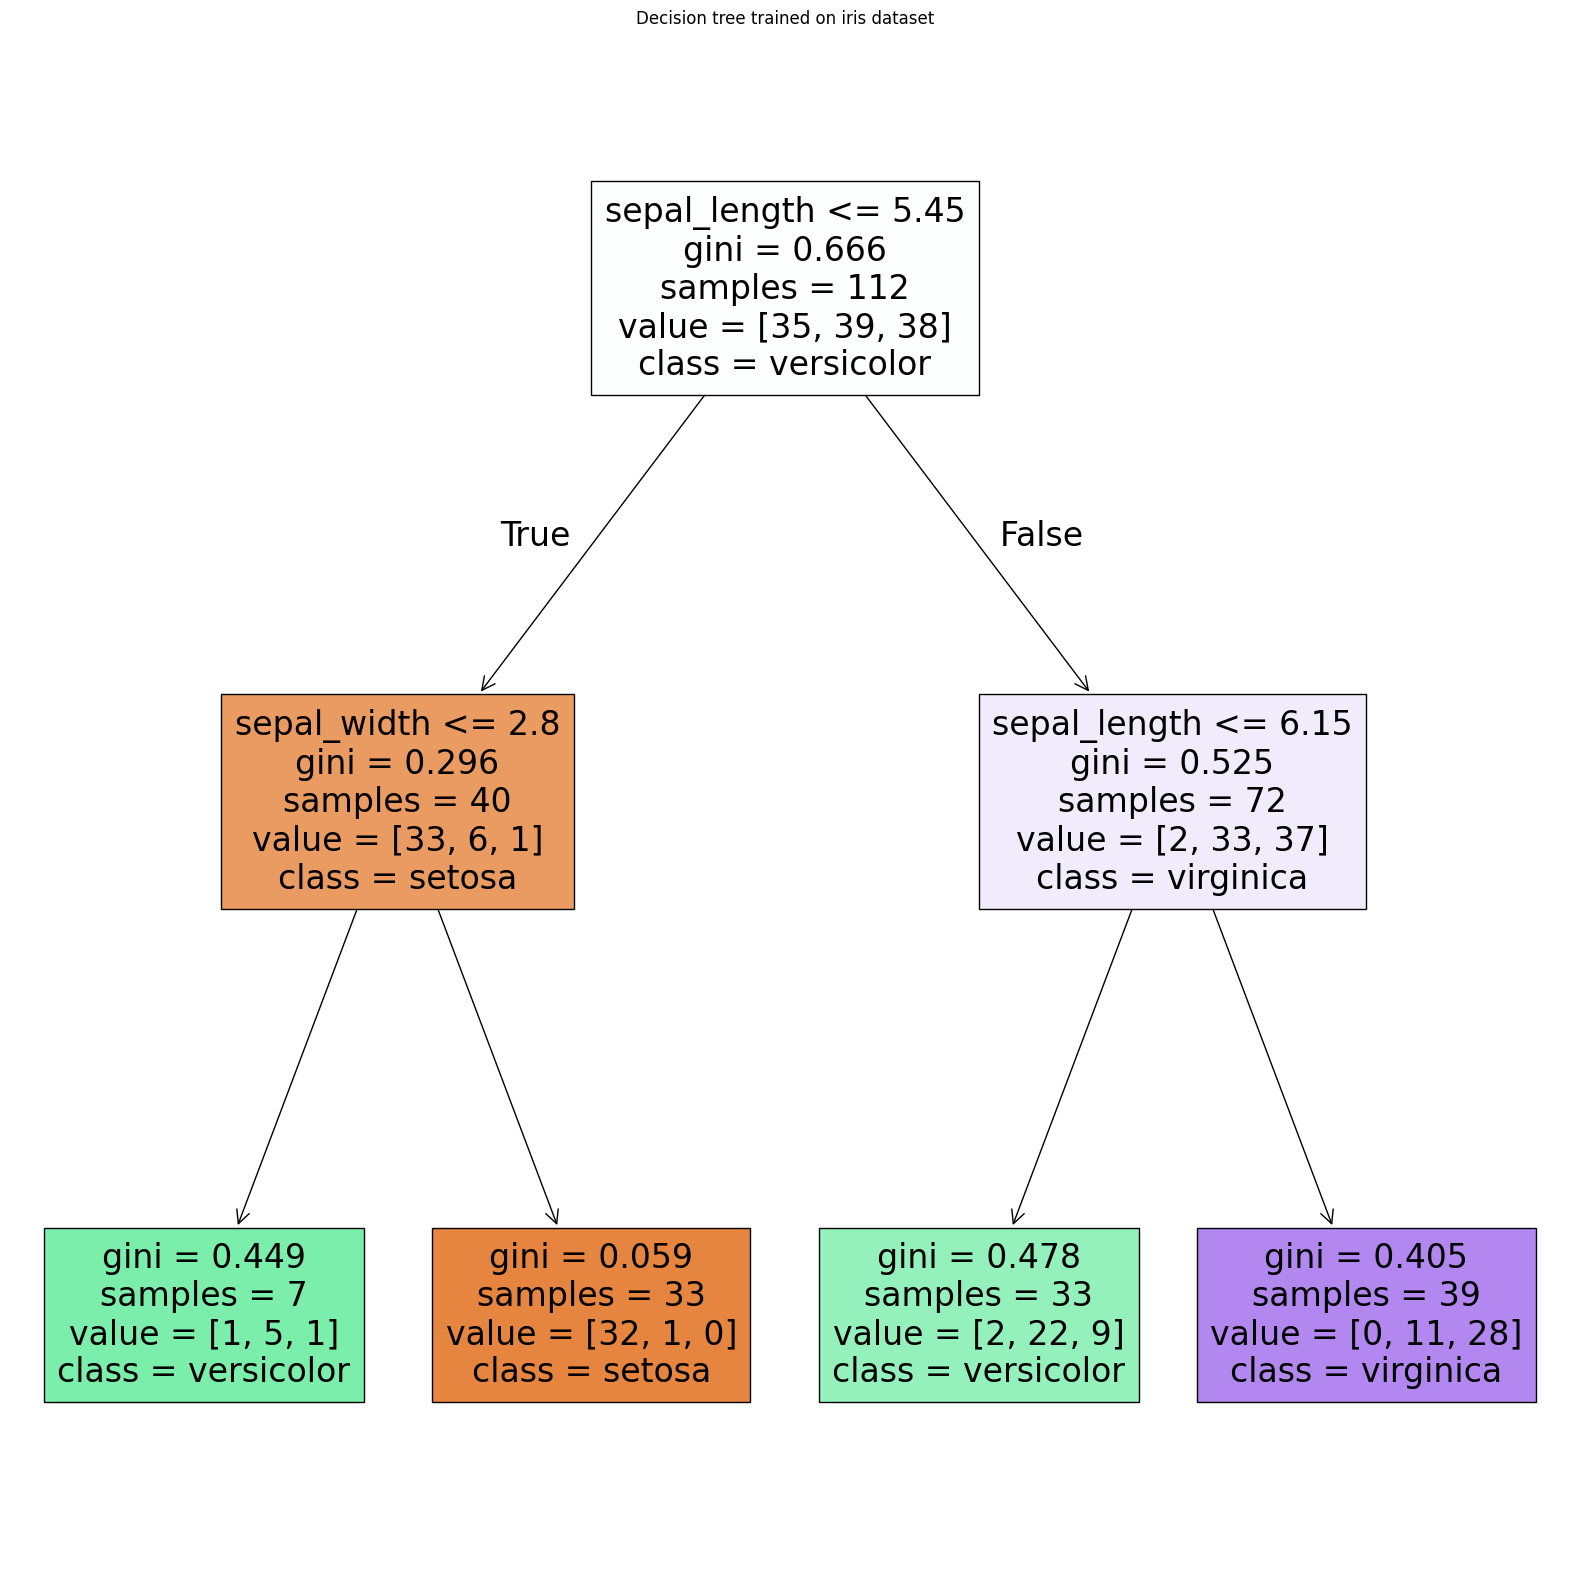

In [4]:
# Plotting the Decision Tree
plt.figure(figsize=(20,20))
col_names = ['sepal_length', 'sepal_width']
plot_tree(decision_tree, filled=True, feature_names=col_names, class_names=iris_ds.target_names)
plt.title("Decision tree trained on iris dataset")
plt.show()

# Visualize the hierarchical structure of the tree
plot_tree(decision_tree, filled=True)
plt.show()

### Interpretation of the Decision Tree Plot

This tree visualization shows the sequence of decisions made by the model:

- **Root Node (Top)**: The first, most important question to split the data (base node).
- **Internal Nodes**: Subsequent splits that further divide the subgroups to reduce impurity.
- **Leaf Nodes (Bottom)**: The final predictions, where our model arrives at a specific class. The `value` array shows how many samples fall into each class at that node.

In [5]:
# Print the text representation of the tree
tree_text = export_text(decision_tree, feature_names=col_names)
print(tree_text)

|--- sepal_length <= 5.45
|   |--- sepal_width <= 2.80
|   |   |--- class: 1
|   |--- sepal_width >  2.80
|   |   |--- class: 0
|--- sepal_length >  5.45
|   |--- sepal_length <= 6.15
|   |   |--- class: 1
|   |--- sepal_length >  6.15
|   |   |--- class: 2

